# Do companies that print stock lose to companies that buy it back? 🧾
### Composite equity issuance — a famous Wall-Street factor that *flips sign* on a basket of big survivors

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Replicates here%3F: Busted](https://img.shields.io/badge/Replicates_here%3F-Busted-8b949e?style=flat-square)

There's a classic finding in finance: firms that quietly **issue** a lot of new stock over five years (secondary offerings, stock-based pay, share-funded deals) go on to **underperform**, while firms that **shrink** their share count (buybacks) go on to **outperform**. It's called the *composite equity issuance* effect (Daniel-Titman 2006), and in the full US stock market it's real.

On a basket of 36 big survivors, using free public data, it comes out **backwards** — and that's the honest, interesting story of this study.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** SEC EDGAR filed share counts × yfinance prices, 36 large-cap **survivors**, 2014→2024 formation years. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from composite_issuance import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    RAW, ADJ, SH = data.load_real()
    RAW, ADJ, SH = data.drop_partial_last_year(RAW, ADJ, SH)
else:
    RAW = ADJ = SH = None
print("real cache present:", HAVE_REAL,
      "| names:", (0 if RAW is None else RAW.shape[1]))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2025-12-31', 'fp': '6a1c28a68799', 'n_names': 36, 'n_years': 11, 'form_lo': 2014, 'form_hi': 2024, 'long_mean': 17.35, 'short_mean': 30.57, 'ls_mean': -13.22, 'ls_median': -15.6, 'win_pct': 36, 'win_lo': 15, 'win_hi': 65, 'sharpe': -0.69, 't': -2.29, 'nw_t': -2.69, 'placebo_p': 0.9972, 'placebo_mean': -0.02, 'width': {0.2: (-17.59, -2.34, -0.71), 0.3: (-13.22, -2.29, -0.69), 0.4: (-12.18, -2.3, -0.69)}, 'era_early_mean': -19.6, 'era_early_n': 6, 'era_early_t': -10.16, 'era_late_mean': -5.55, 'era_late_n': 5, 'era_late_t': -0.45, 'era_diff_t': 1.13, 'cost_net': -13.92, 'cost_net_t': -2.41, 'cost_bps': 10, 'borrow_bps': 50, 'syn_null_t': 0.13, 'syn_null_mean': 0.81, 'syn_planted_t': 7.8, 'syn_planted_mean': 28.38, 'years': [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], 'ls_by_year': [-13.4, -22.2, -19.2, -20.8, -26.6, -15.6, 4.4, 8.4, -54.7, 7.1, 7.0]}


real cache present: True | names: 36


## The answer first

| Question | Answer |
|---|---|
| Do low-issuance (buyback) firms beat high-issuance (diluting) firms here? | **No — the opposite.** The buyback basket averaged **+17%/yr** while the diluters averaged **+31%/yr**. Betting on the factor the textbook way *lost* **-13%/yr**. |
| Is that just bad luck / noise? | **No — it's significant, in the wrong direction.** *t* = -2.29 (the bar is ±2). A random reshuffle of the signal beats the real sort **100%** of the time. |
| So the famous factor is fake? | **No — our *basket* is the problem.** We only kept companies that *survived* to 2026. The big issuers that survived are exactly the ones whose stock printing funded growth that **worked** (think mega-cap tech). The losers were deleted before we ever looked. |
| Could you at least trade the reverse? | **Not really.** The wrong-sign effect is almost entirely a **pre-2020** phenomenon; since 2020 it's basically gone. |

> The lesson isn't "the factor is wrong." It's how violently **survivorship bias** can flip a real result on a small, hand-picked basket of winners.

## 1 · The claim

> *"Watch how fast a company's market value grows versus how much its stock actually returned. The gap is equity issuance — new shares creeping in. Serial issuers underperform; net buyback-ers outperform."*

This is **composite equity issuance** (Daniel & Titman, 2006). Over five years, take the growth in a firm's total market cap and subtract what its stock return alone would have delivered. Whatever's left is the firm quietly changing its share base — issuing (bad) or repurchasing (good). It's a cousin of our [Study 519](../../519-net-share-issuance/) (which uses the *1-year raw share-count* change); this is the broader **5-year log** version.

## 2 · So what?

If it held on a basket you could actually assemble from free data, it'd be a simple, mechanical stock screen: rank your names by how much stock they've been printing, buy the repurchasers, avoid the diluters. No forecasting. The whole point of this desk, though, is to check whether a famous factor *survives contact* with a small, honestly-built, survivorship-flavoured sample — because that's the sample most people can actually build.

## 3 · How would we even know?

- **The measure.** For each of 36 big survivors, at each year-end, the 5-year growth in market cap minus the 5-year stock return — using **share counts as they were actually filed** with the SEC (no peeking at future filings).
- **The sort.** Buy the third with the *lowest* issuance (buyback-ers), short the third with the *highest* (diluters), hold one year, repeat.
- **The luck check.** Randomly shuffle which company gets which issuance number 20,000 times — how often does a random label beat the real one?
- **The mirage check.** What would make us say "survivorship, not signal"? A synthetic world where we *plant* the real effect and confirm our sorter would catch it pointing the *right* way — so a wrong-sign result on the real tape is the sample, not a bug.

## 4 · The teardown — let's actually look

**First, the two baskets.** Average yearly return of the buyback-ers vs the diluters.

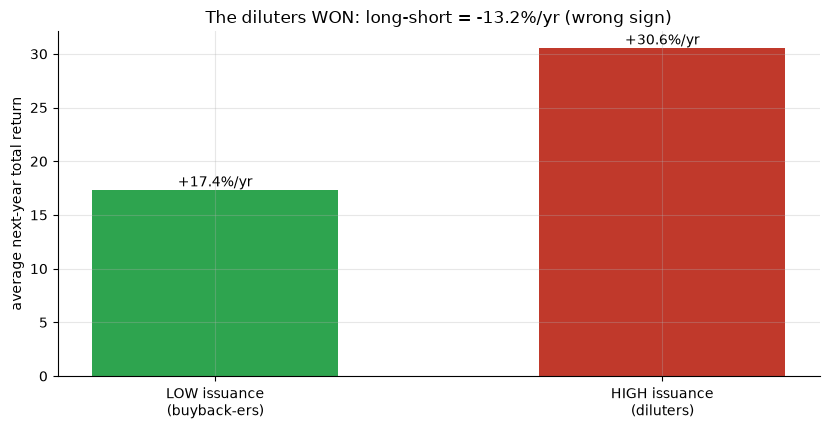

buyback-ers +17.4%/yr | diluters +30.6%/yr | long-short -13.2%/yr


In [2]:
if HAVE_REAL:
    s = st.summarize(RAW, ADJ, SH, frac=0.3, placebo=False)
    lo, hi, ls = s['long_mean']*100, s['short_mean']*100, s['ls_mean']*100
else:
    lo, hi, ls = R['long_mean'], R['short_mean'], R['ls_mean']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['LOW issuance\n(buyback-ers)','HIGH issuance\n(diluters)'], [lo, hi],
       color=[GREEN, RED], width=.55)
for i,v in enumerate([lo, hi]): ax.annotate(f'{v:+.1f}%/yr',(i,v),ha='center',va='bottom')
ax.set_ylabel('average next-year total return')
ax.set_title(f'The diluters WON: long-short = {ls:+.1f}%/yr (wrong sign)')
plt.tight_layout(); plt.show()
print(f'buyback-ers {lo:+.1f}%/yr | diluters {hi:+.1f}%/yr | long-short {ls:+.1f}%/yr')

The textbook says the green bar should win. Here the **red bar wins by 13 points a year** — the high-issuance survivors (+31%/yr) crushed the buyback-ers (+17%/yr). The factor didn't just fail to show up; it **inverted**.

**Was every year like that, or a couple of blowups?**

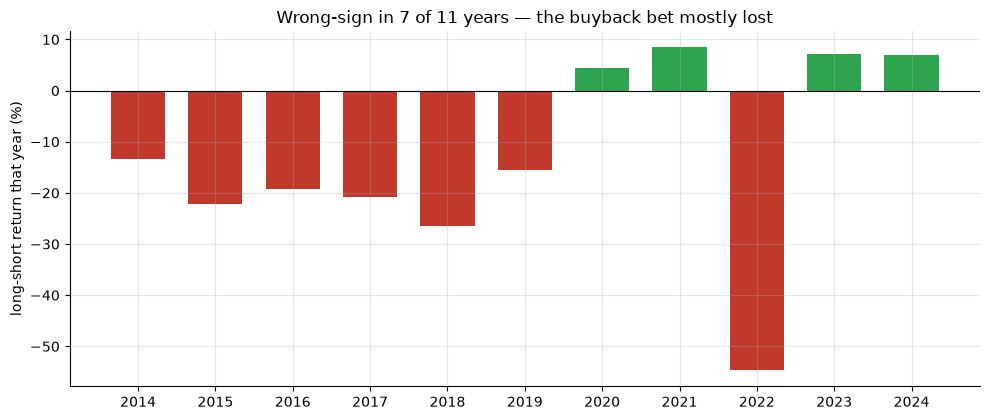

{2014: -13.4, 2015: -22.2, 2016: -19.2, 2017: -20.8, 2018: -26.6, 2019: -15.6, 2020: 4.4, 2021: 8.4, 2022: -54.7, 2023: 7.1, 2024: 7.0}


In [3]:
if HAVE_REAL:
    ls_s = st.long_short_series(RAW, ADJ, SH, frac=0.3)
    yrs = [d.year for d in ls_s.index]; vals = list(ls_s['ls_ret']*100)
else:
    yrs, vals = R['years'], R['ls_by_year']
fig, ax = plt.subplots(figsize=(10.0, 4.3))
cols = [GREEN if v>0 else RED for v in vals]
ax.bar([str(y) for y in yrs], vals, color=cols, width=.7)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('long-short return that year (%)')
ax.set_title('Wrong-sign in 7 of 11 years — the buyback bet mostly lost')
plt.tight_layout(); plt.show()
print({y: round(v,1) for y,v in zip(yrs, vals)})

Red in **7 of 11** years (win-rate 36%). It's not one crash dragging the average — the buyback bet lost the *majority* of years. And a random reshuffle of the issuance labels beats the real sort **100%** of the time, so the real link between issuance and returns is close to the *worst* it could be for the claim.

**So is the famous factor just wrong? No — watch what our sorter does when the effect is really there.**

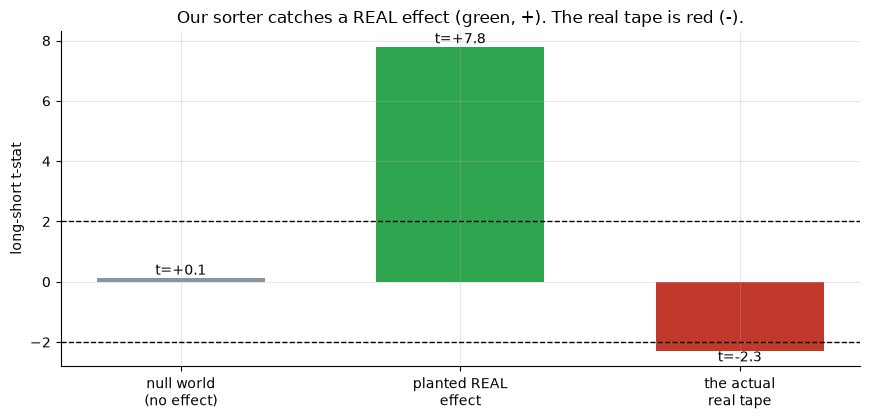

null t=+0.13 | planted t=+7.80 | real tape t=-2.29


In [4]:
rows = st.synthetic_control(data.synthetic_panel, edges=(0.0, 0.12), n_seeds=25)
null_t = next(r for r in rows if r['edge']==0.0)['mean_t']
plant_t = next(r for r in rows if r['edge']==0.12)['mean_t']
real_t = R['t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(['null world\n(no effect)','planted REAL\neffect','the actual\nreal tape'],
       [null_t, plant_t, real_t], color=[GREY, GREEN, RED], width=.6)
for i,v in enumerate([null_t, plant_t, real_t]):
    ax.annotate(f't={v:+.1f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(2, ls='--', c='k', lw=1); ax.axhline(-2, ls='--', c='k', lw=1)
ax.set_ylabel('long-short t-stat')
ax.set_title('Our sorter catches a REAL effect (green, +). The real tape is red (-).')
plt.tight_layout(); plt.show()
print(f'null t={null_t:+.2f} | planted t={plant_t:+.2f} | real tape t={real_t:+.2f}')

When we *plant* a genuine buyback edge, our sorter lights up **positive** (t = +7.8); with no effect it sits at zero (t = +0.13). The real tape comes out **negative** (t = -2.29). The machinery is fine and points the right way when the effect is real — so the wrong sign on the real tape is a fact about our **basket of survivors**, not a broken detector.

## 5 · The verdict

- **Signal — None.** The buyback-minus-diluter bet lost **-13%/yr** at *t* = -2.29 — significant, but the **wrong sign**. On this survivor basket the famous factor doesn't replicate; it inverts.
- **Tradability — Mirage.** You can't trade a wrong-sign factor, and the reverse bet is a pre-2020-only survivorship artifact. Costs only make it worse.
- **"Does the published factor replicate here?" — Busted.** A canonical academic result, honestly rebuilt on a small survivor basket, flips sign — a textbook small-sample / survivorship lesson, not a free lunch.

## 6 · Going further 🚪

- **The real fix** is a point-in-time, survivorship-free universe (CRSP/Compustat), where the delisted issuers are still in the sample and the effect shows up the right way. That's the difference between the published result and a free-data replication.
- **Why survivors invert it:** the surviving big issuers are a *selected* set — the ones whose stock printing (stock-based comp, acquisitions) funded growth that actually worked. The issuers who diluted their way into oblivion aren't in the basket at all.
- **Sibling studies:** [519-net-share-issuance](../../519-net-share-issuance/) (the 1-year raw share-count version — also `None` here), [368-buyback-drift](../../368-buyback-drift/) (the announcement *event*), and [250-reverse-split](../../250-reverse-split/) (a corporate-action signal). See [docs/references.md](docs/references.md) for the exact dedup.

*Think the factor survives on free data? Build a point-in-time survivor-free basket and show a positive, certifiable long-short after costs — then we'll talk.*